Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-wqy-microhei is already the newest version (0.2.0-beta-3.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
現在訓練：sgd
迭代=400, w=0.5267681846151817, b=8.282263763703695e-18, loss=0.27107608407590883
迭代=800, w=0.7632708566487005, b=1.7164047960705202e-17, loss=0.1234054082336256
迭代=1200, w=0.8694532638490426, b=2.604583215770671e-17, loss=0.0936389411390159
迭代=1600, w=0.917125890555185, b=2.77555756156295e-17, loss=0.08763881580444507
迭代=2000, w=0.9385294299642644, b=2.77555756156295e-17, loss=0.08642935067322426
現在訓練：momentum
迭代=400, w=0.525078228940715, b=7.971736252428941e-18, loss=0.27254941696473833
迭代=800, w=0.7653932508145661, b=1.6853185513809974e-17, loss=0.12259142382946422
迭代=1200, w=0.8716804283029455, b=2.573496971081148e-17, loss=0.09325754253044279
迭代=1600, w=0.9186894084755475, b=2.795541576006184e-17, loss=0.08751942498115776
迭代=2000, w=0.9394806672998742

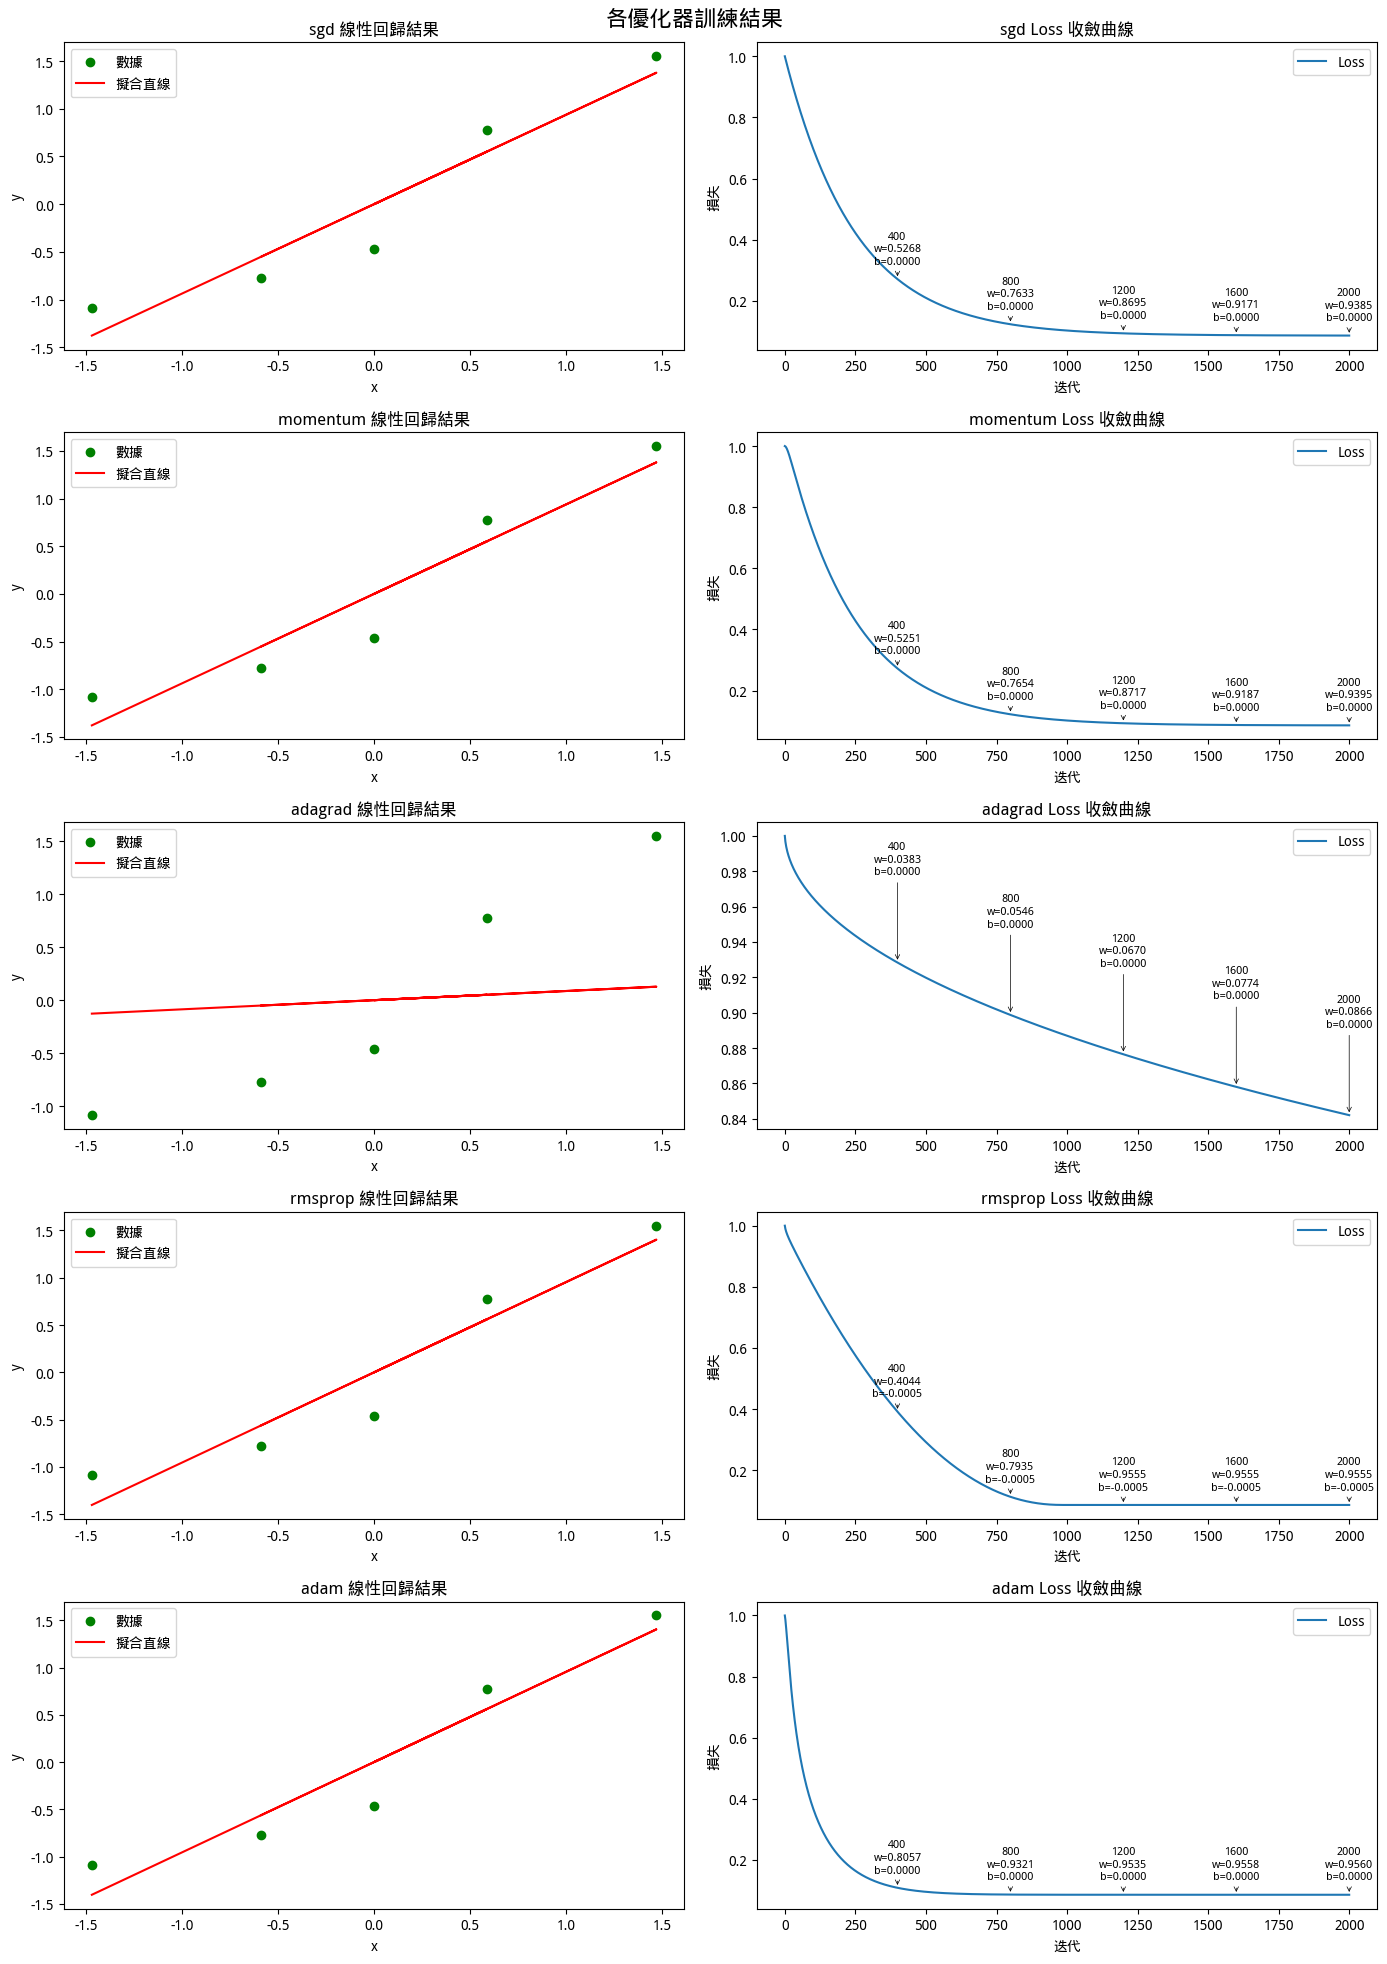

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Install Chinese font
!sudo apt-get -y install fonts-wqy-microhei

# Add the specific font file to matplotlib's font manager
font_path = '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# Configure font settings
plt.rcParams['font.family'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

x1 = np.array([166, 176, 171, 173, 169], dtype=float)
y_true1 = np.array([58, 75, 62, 70, 60], dtype=float)

x = (x1 - np.mean(x1)) / np.std(x1)
y_true = (y_true1 - np.mean(y_true1)) / np.std(y_true1)

n = 5
learning_rate = 0.001

def train(method):
    w = 0
    b = 0
    state = {} # 儲存優化器狀態
    loss_history = []
    param_history = []
    arrow = [400, 800, 1200, 1600, 2000]

    for i in range(2000):
        y_pred = w * x + b
        loss = np.mean((y_pred - y_true) ** 2)

        dw = (2 / n) * np.sum((y_pred - y_true) * x)
        db = (2 / n) * np.sum(y_pred - y_true)

        if method == "sgd":
            w -= learning_rate * dw
            b -= learning_rate * db

        elif method == "momentum":
            beta = 0.9
            v_w = state.get("v_w", 0)
            v_b = state.get("v_b", 0)
            v_w = beta * v_w + (1 - beta) * dw
            v_b = beta * v_b + (1 - beta) * db
            w -= learning_rate * v_w
            b -= learning_rate * v_b
            state["v_w"] = v_w
            state["v_b"] = v_b

        elif method == "adagrad":
            G_w = state.get("G_w", 0)
            G_b = state.get("G_b", 0)
            G_w += dw ** 2
            G_b += db ** 2
            w -= learning_rate * dw / (np.sqrt(G_w) + 1e-8)
            b -= learning_rate * db / (np.sqrt(G_b) + 1e-8)
            state["G_w"] = G_w
            state["G_b"] = G_b

        elif method == "rmsprop":
            beta = 0.9
            G_w = state.get("G_w", 0)
            G_b = state.get("G_b", 0)
            G_w = beta * G_w + (1 - beta) * dw ** 2
            G_b = beta * G_b + (1 - beta) * db ** 2
            w -= learning_rate * dw / (np.sqrt(G_w) + 1e-8)
            b -= learning_rate * db / (np.sqrt(G_b) + 1e-8)
            state["G_w"] = G_w
            state["G_b"] = G_b

        elif method == "adam":
            beta1 = 0.9
            beta2 = 0.999
            m_w = state.get("m_w", 0)
            v_w = state.get("v_w", 0)
            m_b = state.get("m_b", 0)
            v_b = state.get("v_b", 0)
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * dw ** 2
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * db ** 2
            w -= learning_rate * m_w / (np.sqrt(v_w) + 1e-8)
            b -= learning_rate * m_b / (np.sqrt(v_b) + 1e-8)
            state["m_w"] = m_w
            state["v_w"] = v_w
            state["m_b"] = m_b
            state["v_b"] = v_b

        loss_history.append(loss)
        if (i + 1) in arrow:
            param_history.append((i + 1, w, b))

        if (i+1) % 400 == 0:
            print(f"迭代={i+1}, w={w}, b={b}, loss={loss}")

    return w, b, loss_history, param_history

methods = ["sgd", "momentum", "adagrad", "rmsprop", "adam"]
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("各優化器訓練結果", fontsize=16, fontweight='bold')

for row, m in enumerate(methods):
    print(f"現在訓練：{m}")
    w, b, loss_history, param_history = train(m)

    ax1 = axes[row, 0]
    ax1.scatter(x, y_true, color='green', label="數據")
    ax1.plot(x, w * x + b, color='red', label="擬合直線")
    ax1.set_title(f"{m} 線性回歸結果")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend()

    ax2 = axes[row, 1]
    ax2.plot(loss_history, label="Loss")
    ax2.set_title(f"{m} Loss 收斂曲線")
    ax2.set_xlabel("迭代")
    ax2.set_ylabel("損失")

    for epoch, w_i, b_i in param_history:
        ax2.annotate(
            f"{epoch}\nw={w_i:.4f}\nb={b_i:.4f}",
            xy=(epoch - 1, loss_history[epoch - 1]),
            xytext=(epoch - 1, loss_history[epoch - 1] + 0.05),
            arrowprops=dict(arrowstyle='->', lw=0.5),
            fontsize=8,
            ha='center'
        )
    ax2.legend()

plt.tight_layout()
plt.show()